# **Loading the Dataset**

In [ ]:
import pandas as pd
df=pd.read_csv("/content/sample_data/car details v4.csv")
df

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,Mahindra,XUV500 W8 [2015-2017],850000,2016,90300,Diesel,Manual,Surat,White,First,Individual,2179 cc,138 bhp @ 3750 rpm,330 Nm @ 1600 rpm,FWD,4585.0,1890.0,1785.0,7.0,70.0
2055,Hyundai,Eon D-Lite +,275000,2014,83000,Petrol,Manual,Ahmedabad,White,Second,Individual,814 cc,55 bhp @ 5500 rpm,75 Nm @ 4000 rpm,FWD,3495.0,1550.0,1500.0,5.0,32.0
2056,Ford,Figo Duratec Petrol ZXI 1.2,240000,2013,73000,Petrol,Manual,Thane,Silver,First,Individual,1196 cc,70 bhp @ 6250 rpm,102 Nm @ 4000 rpm,FWD,3795.0,1680.0,1427.0,5.0,45.0
2057,BMW,5-Series 520d Luxury Line [2017-2019],4290000,2018,60474,Diesel,Automatic,Coimbatore,White,First,Individual,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm,RWD,4936.0,1868.0,1479.0,5.0,65.0


# **Data Exploration**

## **Getting the distribution of each numerical features using Histogram**

### **Cleaning Engine, Max Power and Max Torque early to fit into numerical features since the values of these features include texts**

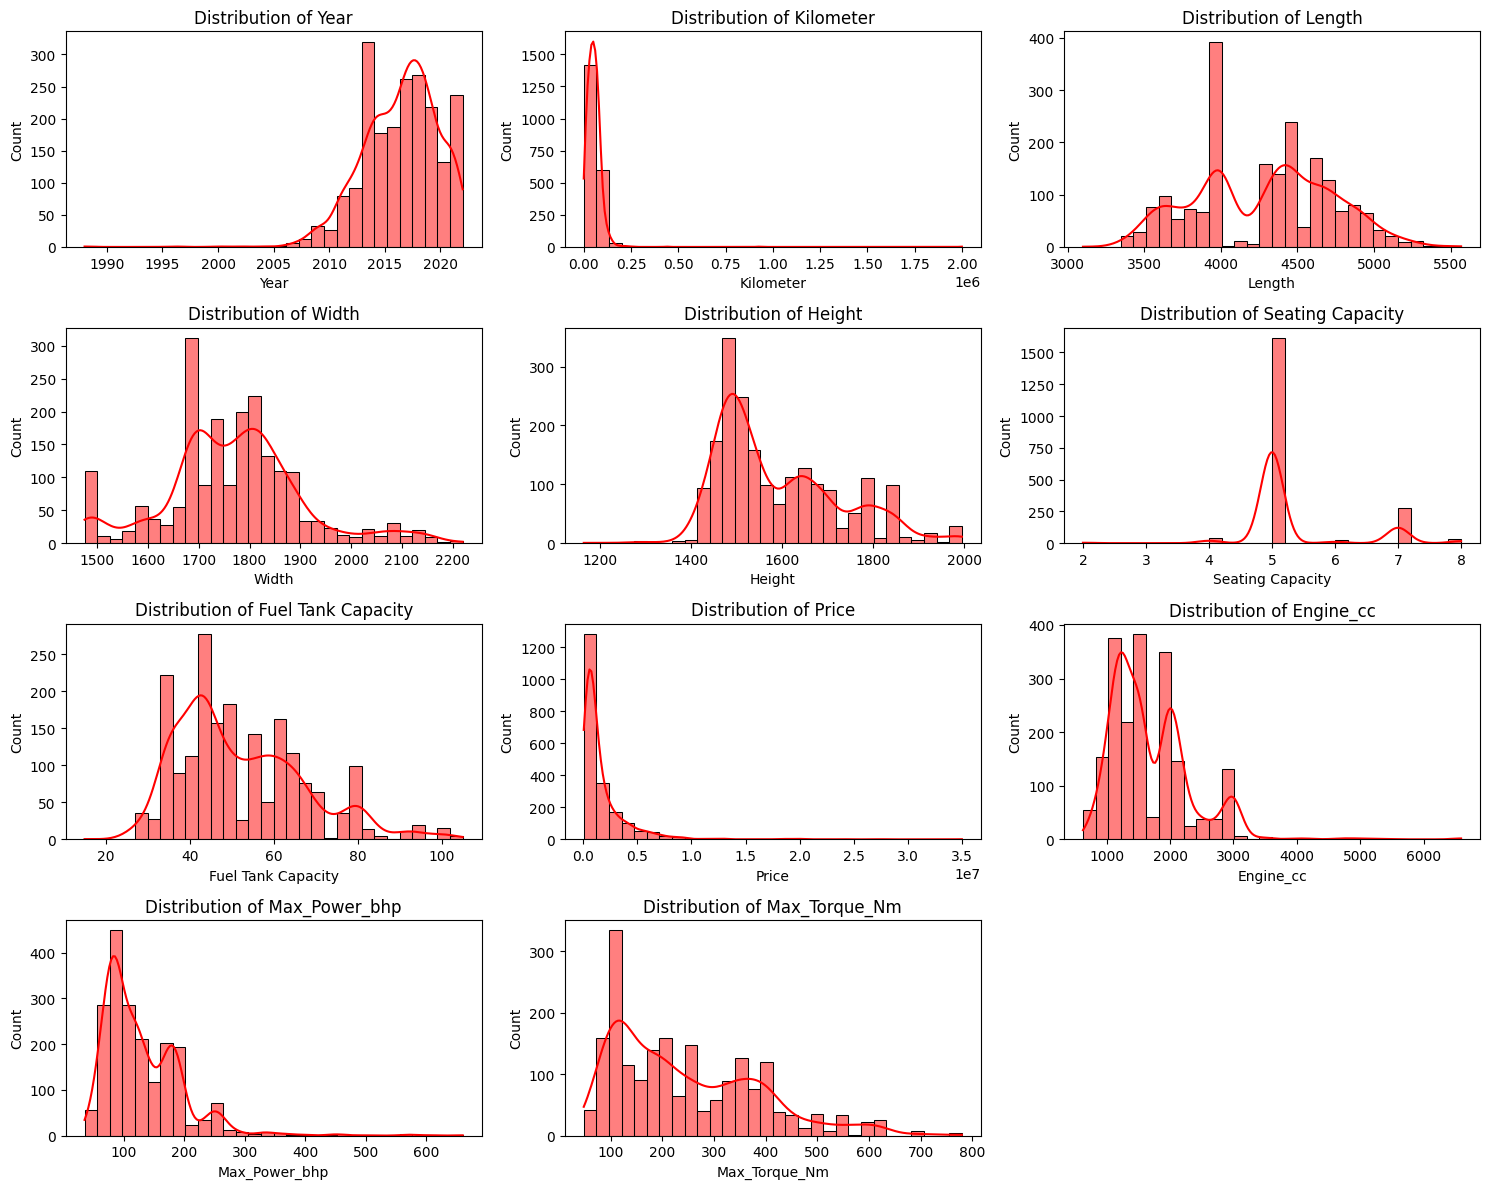

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Engine_cc'] = df['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Max_Power_bhp'] = df['Max Power'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Max_Torque_Nm'] = df['Max Torque'].str.extract(r'(\d+\.?\d*)').astype(float)

df = df.drop(columns=['Engine', 'Max Power', 'Max Torque'])
num_features = ['Year', 'Kilometer', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', 'Price', 'Engine_cc', 'Max_Power_bhp', 'Max_Torque_Nm']

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_features, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='red')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## **Analyzing the frequencies of the categorical features**

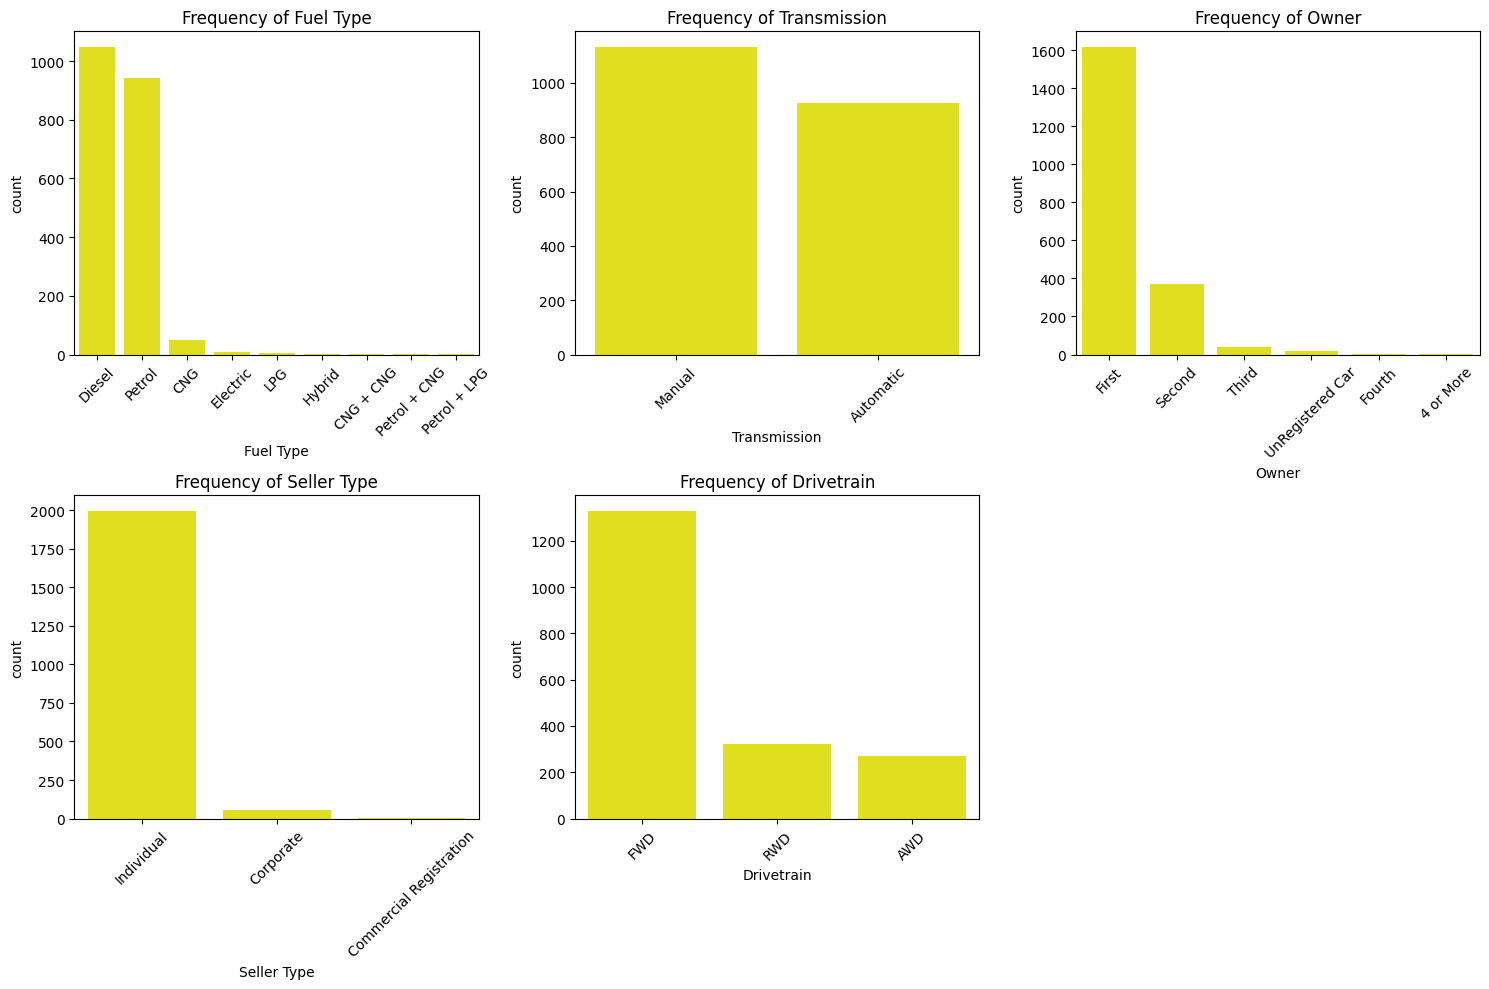

In [ ]:
cat_features = ['Fuel Type', 'Transmission', 'Owner', 'Seller Type', 'Drivetrain']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, color='yellow')
    plt.title(f'Frequency of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Comparing the target price column with numerical features using scatter plot**

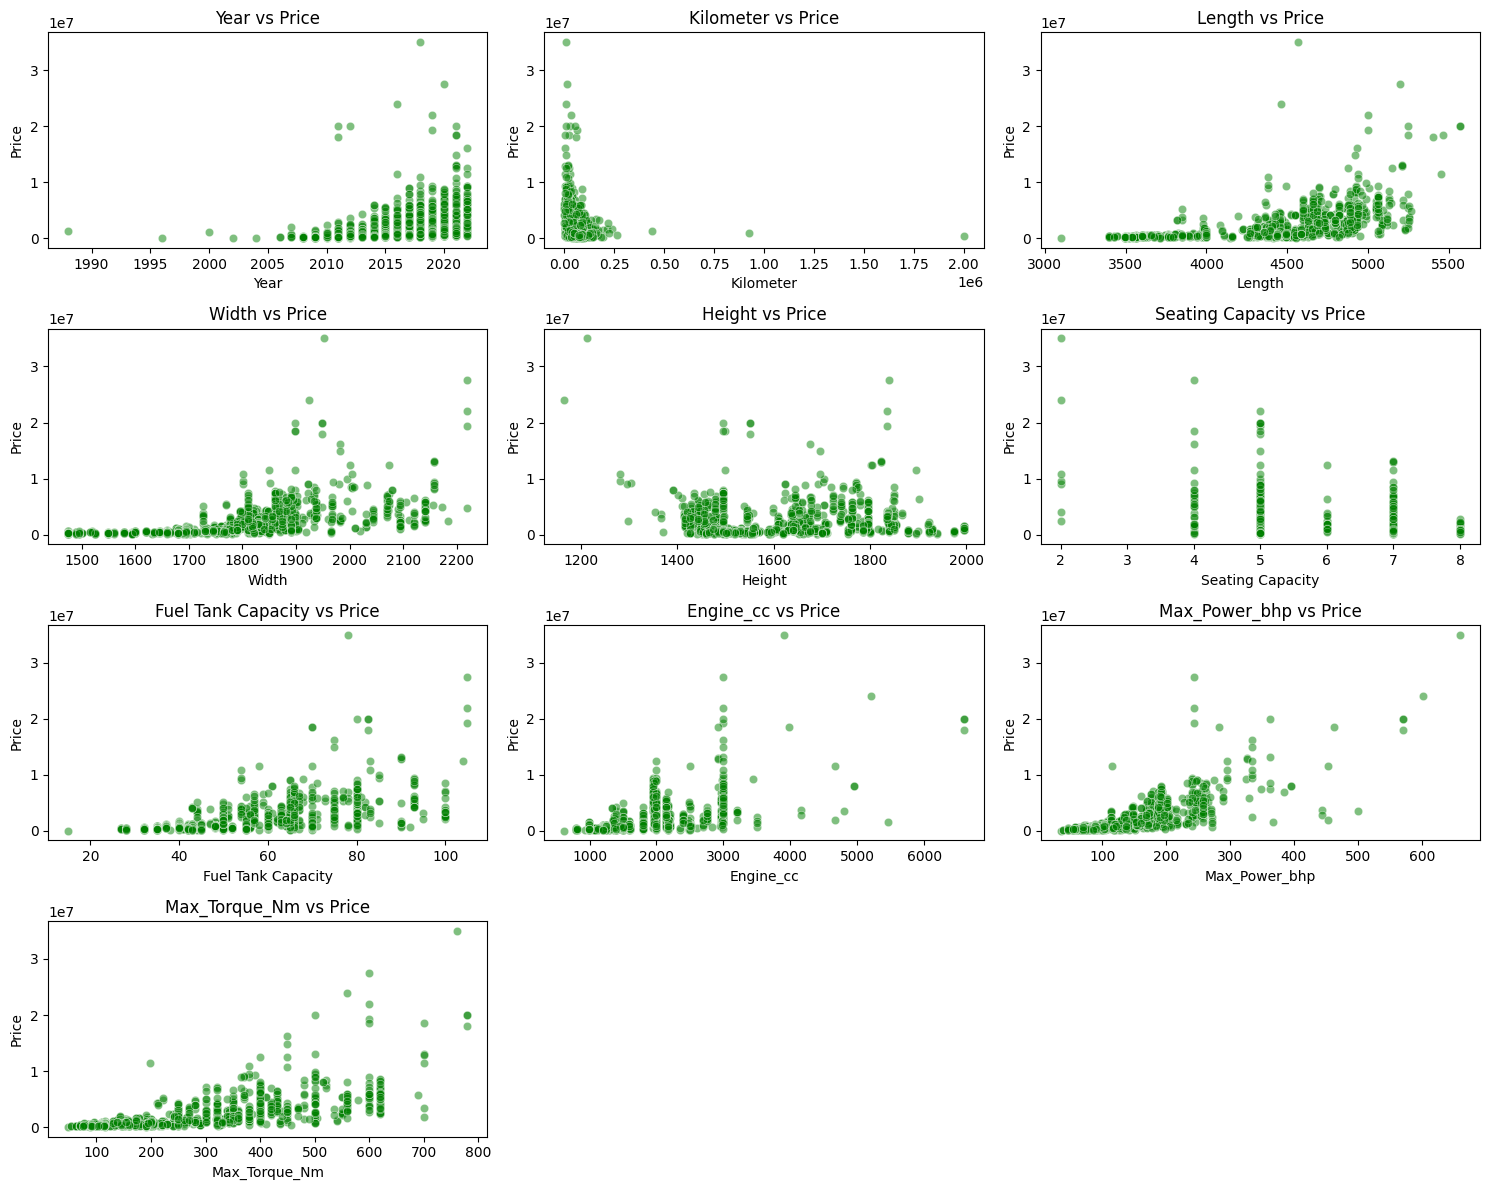

In [ ]:
plt.figure(figsize=(15, 12))
num_features_no_target = [col for col in num_features if col != 'Price']

for i, col in enumerate(num_features_no_target, 1):
    plt.subplot(4, 3, i)
    sns.scatterplot(data=df, x=col, y='Price', alpha=0.5, color='green')
    plt.title(f'{col} vs Price')
plt.tight_layout()
plt.show()



## **Analyzing Correlation Matrix**

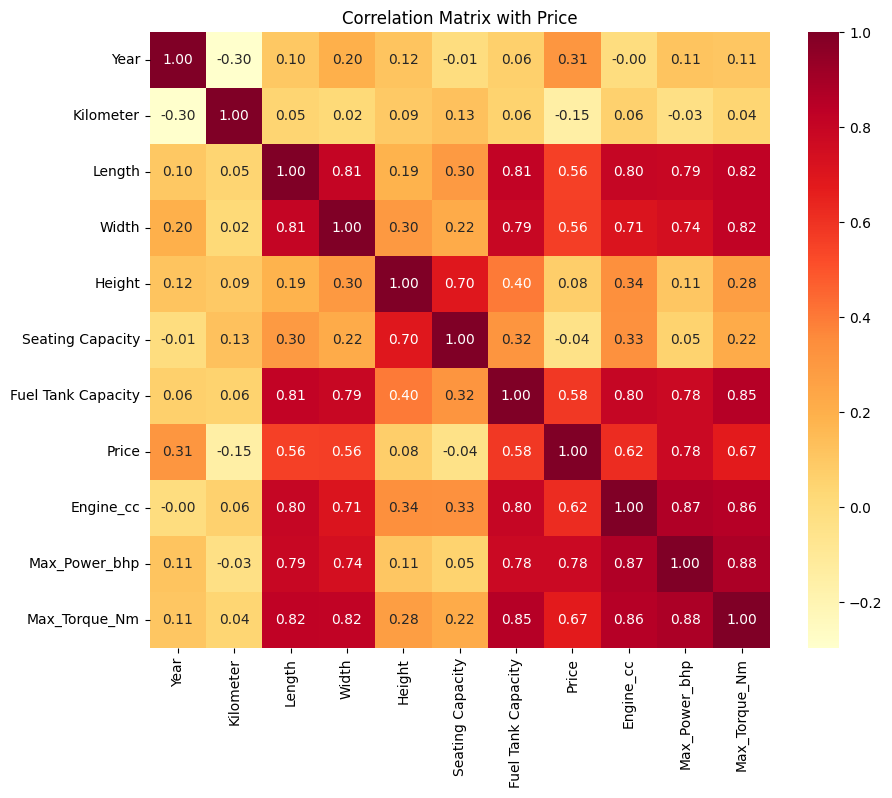

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_features].corr(), annot=True, cmap='YlOrRd', fmt=".2f")
plt.title('Correlation Matrix with Price')
plt.show()

## **Comparing categorical features with the target Price using boxplot**

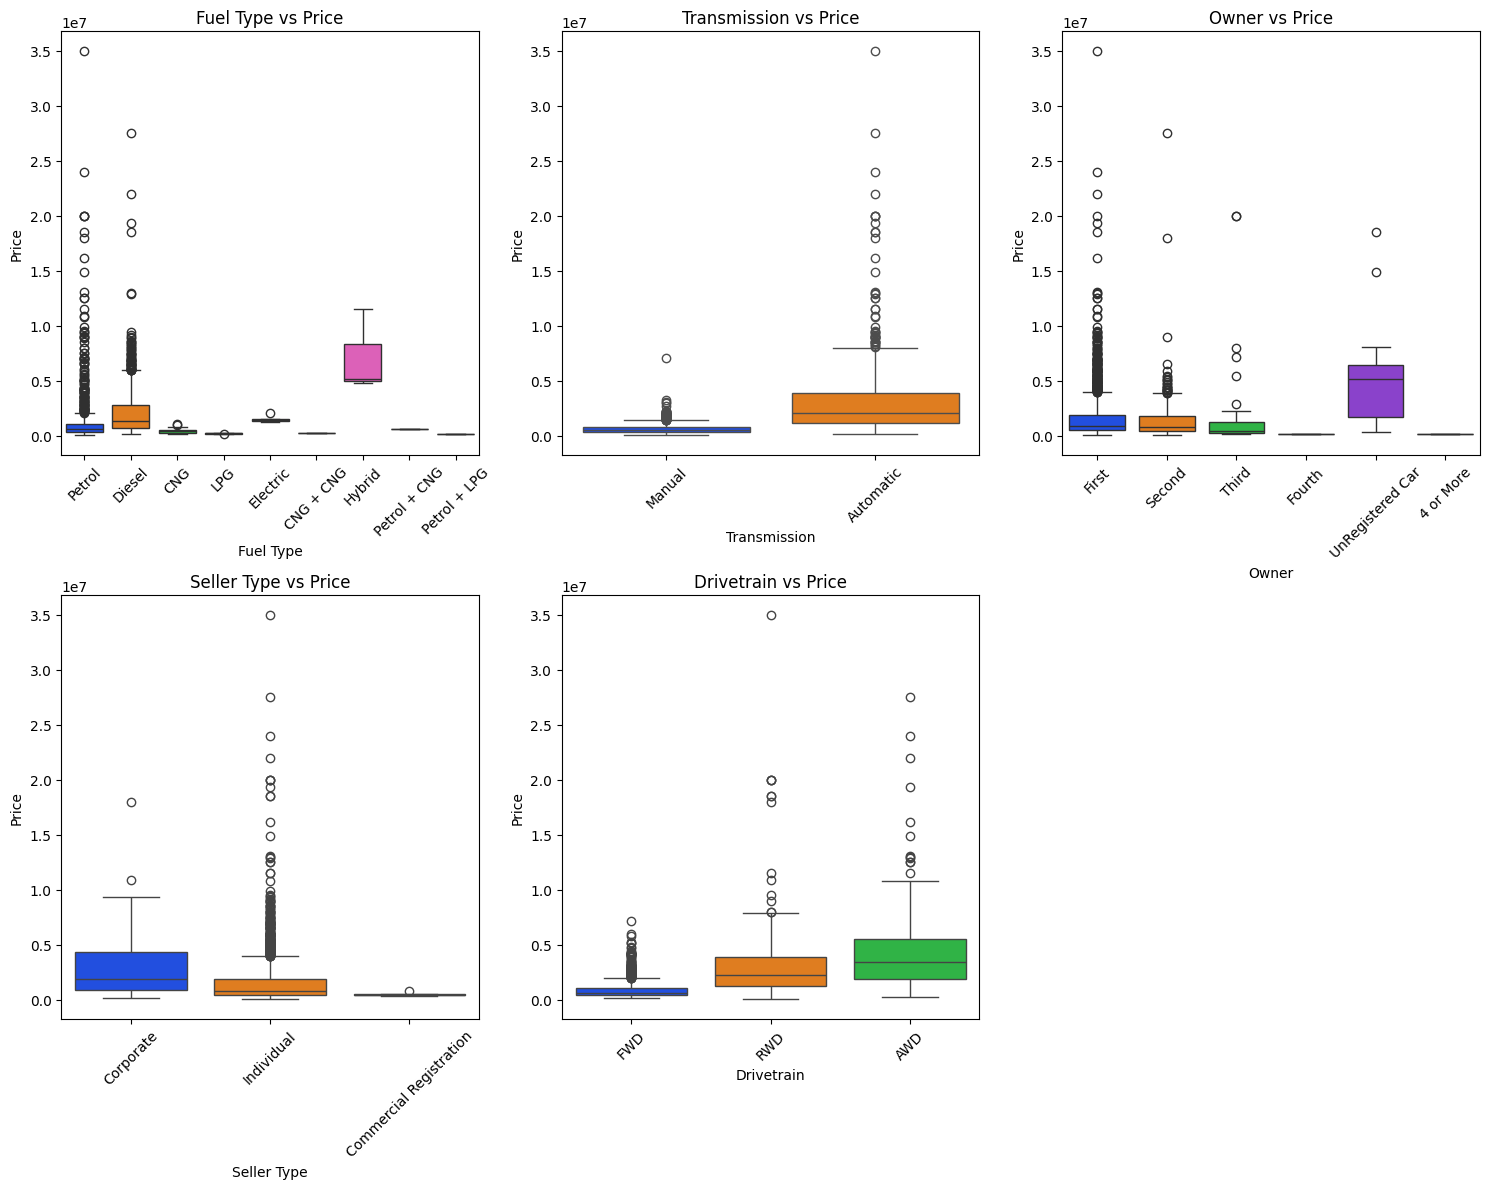

In [ ]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x=col, y='Price', hue=col, palette='bright', legend=False)
    plt.title(f'{col} vs Price')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Data Preprocessing**

### **Checking for missing values**

In [ ]:
df.isnull().sum().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


### **Importing necessary libraries and modules**

### **Introducing X(Predictors) and y(Target)**

### **Dropping Price, Model, Location and Color from the Dataframe to create X**

### **Since Price is the target and the other three suffers from high cardinality**

### **Splitting them into training and testing sets**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


X = df.drop(columns=['Price', 'Model','Location','Color'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Grouping the features so that we can perform appropriate imputations**

In [ ]:
num_cols_median = ['Year', 'Kilometer', 'Length', 'Width', 'Height', 'Fuel Tank Capacity', 'Engine_cc', 'Max_Power_bhp', 'Max_Torque_Nm']
num_cols_mode = ['Seating Capacity']
cat_cols = ['Make', 'Fuel Type', 'Transmission', 'Owner', 'Seller Type', 'Drivetrain']


### **Capping the outliers of numerical columns using IQR method**

### **Creating independent copies of the dataframes, making sure that I don't accidently corrupt the original one**

### **Using a for loop,creating IQR method**

### **Using numpy's clip function making sure that the values are inside lower bound and upper bound, ignoring the values if it is already inside the boundary**

In [ ]:
def cap_outliers_iqr(train_df, test_df, columns):
    train_capped = train_df.copy()
    test_capped = test_df.copy()

    for col in columns:
        q1 = train_df[col].quantile(0.25)
        q3 = train_df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        train_capped[col] = np.clip(train_capped[col], lower_bound, upper_bound)
        test_capped[col] = np.clip(test_capped[col], lower_bound, upper_bound)

    return train_capped, test_capped

X_train, X_test = cap_outliers_iqr(X_train, X_test, num_cols_median)

### **Using Pipeline for imputation, scaling and encoding**

### **Using ColumnTransformer to send columns to their appropriate pipeline**

### **Getting all the updated features into the final dataframe**

In [ ]:
num_median_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

num_mode_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])


cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num_med', num_median_transformer, num_cols_median),
        ('num_mod', num_mode_transformer, num_cols_mode),
        ('cat', cat_transformer, cat_cols)
    ]
)


X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

encoded_cat_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols)
all_feature_names = num_cols_median + num_cols_mode + list(encoded_cat_names)

X_train_final = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_final = pd.DataFrame(X_test_processed, columns=all_feature_names)
print(f"Processed Shape: {X_train_final.shape}")
print(X_train_final.head())

Processed Shape: (1647, 63)
       Year  Kilometer    Length     Width    Height  Fuel Tank Capacity  \
0 -1.363397   0.760874  0.194318  0.079745 -0.305738           -0.130055   
1 -0.135669   0.807645  0.384723  2.206923 -0.343296            0.762220   
2  0.171263   1.957210  0.681663  0.989133  1.459498            1.242676   
3  1.398992  -1.622863  2.091562  2.214830  1.744941            2.615406   
4  0.785128   0.676267  1.157674  0.712363  1.835081            1.929041   

   Engine_cc  Max_Power_bhp  Max_Torque_Nm  Seating Capacity  ...  \
0  -0.310777      -0.187977      -0.320695         -0.373537  ...   
1   0.548762       0.990760       0.760289         -0.373537  ...   
2   0.552221       0.181478       0.544092          2.112179  ...   
3   2.157155       3.084336       3.282584          2.112179  ...   
4   1.863147       0.814829       1.480945          2.112179  ...   

   Owner_Fourth  Owner_Second  Owner_Third  Owner_UnRegistered Car  \
0           0.0           1.0 

### **Checking for any missing values**

In [ ]:
X_train_final.isnull().sum().sum()

np.int64(0)

# **Model Development**

### **Training the model using Random Forest**

### **Using log transformation on Price since it is heavily right skewed**

### **Setting up the model**

### **Generating log predictions**

### **Reversing the log scale to standard values**




In [ ]:
from sklearn.ensemble import RandomForestRegressor
y_train_log = np.log1p(y_train)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_final, y_train_log)

y_pred_log = model.predict(X_test_final)

y_pred = np.expm1(y_pred_log)

# **Evaluating model's performance**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error",mae)
print("Root Mean Squared Error",rmse)
print("R2 Score",r2)

Mean Absolute Error 311601.6105887332
Root Mean Squared Error 1283269.2951385132
R2 Score 0.7642837722185745


# ***The final model displays a robust predictive power since it can explain 76.4% of variations or fluctuations using independent variables***

# ***It might have an average predicting error of approximately 311601 units(MAE)***

# ***The difference between MAE and RMSE tells you that the model can predict accurately most of the time but there can be few massive error due to outliers***

# ***It can accurately predict most of the cheap car prices, but when it encounters a rare luxury it might miss the actual price by millions of units***